In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

import numpy as np
from matplotlib import pyplot as plt

from utils.common import read_csv_logging

In [3]:
data = read_csv_logging("../../log/arm_right_log.csv")
print(f"Signals: {data.keys()}")

pos = data["O_T_EE"][:,12:15]
pos_cmd = data["O_T_EE_cmd"][:,12:15]
print(len(pos))

Signals: dict_keys(['q', 'q_cmd', 'dq', 'tau_J', 'tau_ext', 'O_T_EE', 'O_T_EE_cmd', 'F_ext', 'time', 'gripper_width', 'state'])
2289


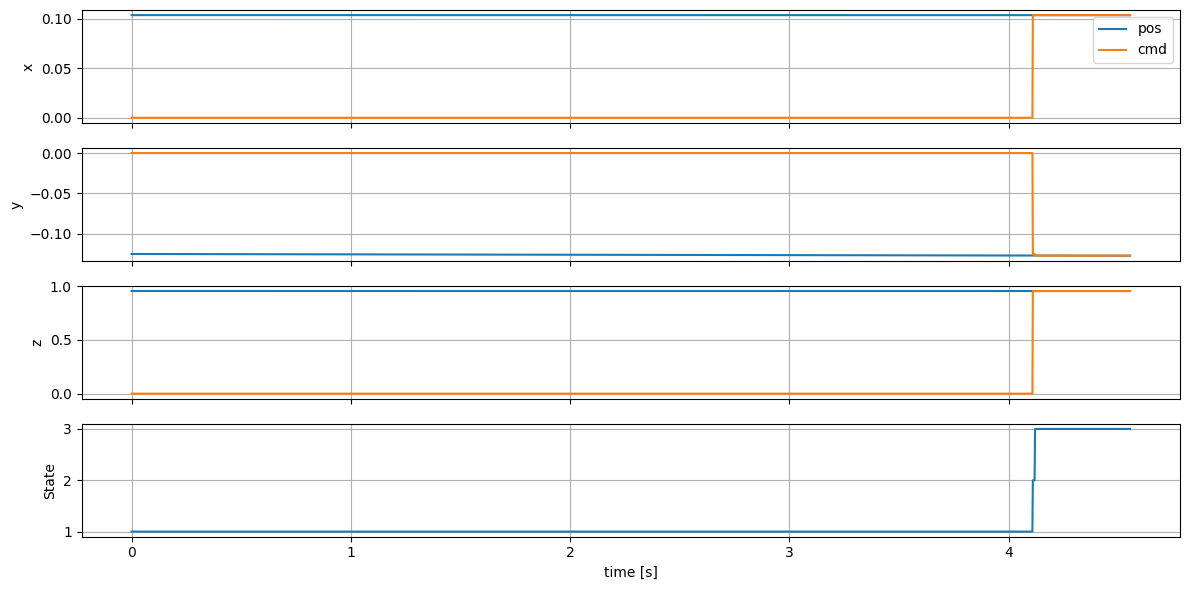

In [4]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(12, 6))

labels = ["x", "y", "z"]

for i in range(3):
    axs[i].plot(data["time"], pos[:, i])
    axs[i].plot(data["time"], pos_cmd[:, i])
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)

axs[3].plot(data["time"], data["state"])
axs[3].grid(True)
axs[3].set_ylabel("State")

axs[0].legend(["pos", "cmd"])
axs[-1].set_xlabel("time [s]")

plt.tight_layout()
plt.show()

plt.show()

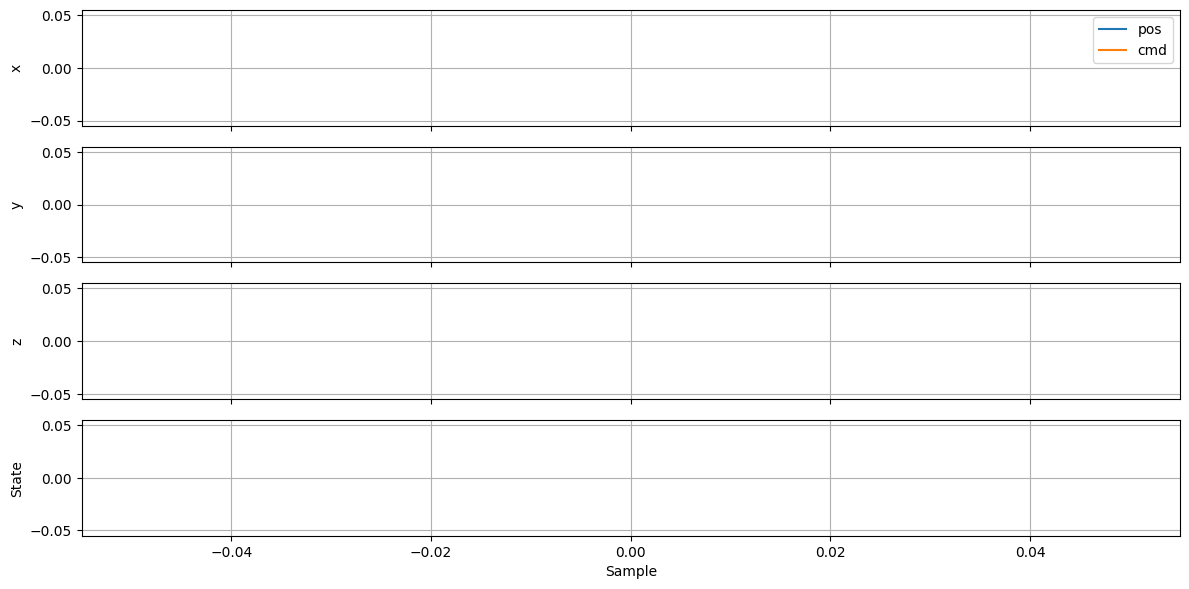

In [5]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(12, 6))
start, stop = 5000, 6000
labels = ["x", "y", "z"]

for i in range(3):
    axs[i].plot(pos[start:stop, i])
    axs[i].plot(pos_cmd[start:stop, i])
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)

axs[3].plot(data["state"][start:stop])
axs[3].grid(True)
axs[3].set_ylabel("State")

axs[0].legend(["pos", "cmd"])
axs[-1].set_xlabel("Sample")

plt.tight_layout()
plt.show()

plt.show()

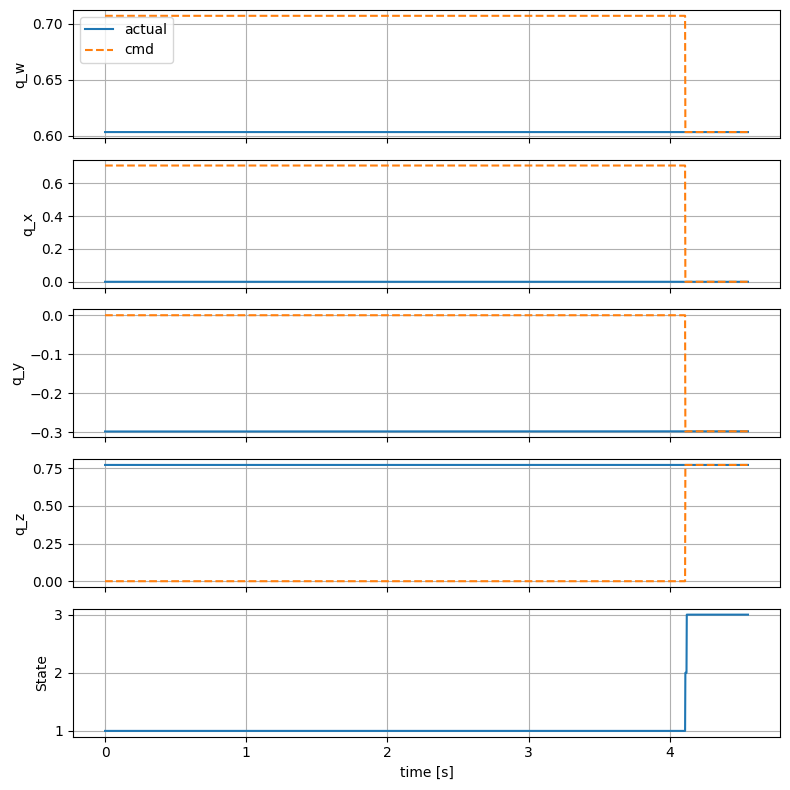

In [6]:
def mat4_to_quat(T_flat):
    """Column-major flat 4x4 → quaternion [w, x, y, z] per row."""
    n = T_flat.shape[0]
    quats = np.zeros((n, 4))
    for i in range(n):
        R = T_flat[i, :9].reshape(3, 3, order='F')  # column-major
        tr = np.trace(R)
        w = np.sqrt(max(0, 1 + tr)) / 2
        x = np.sqrt(max(0, 1 + R[0,0] - R[1,1] - R[2,2])) / 2
        y = np.sqrt(max(0, 1 - R[0,0] + R[1,1] - R[2,2])) / 2
        z = np.sqrt(max(0, 1 - R[0,0] - R[1,1] + R[2,2])) / 2
        x = np.copysign(x, R[2,1] - R[1,2])
        y = np.copysign(y, R[0,2] - R[2,0])
        z = np.copysign(z, R[1,0] - R[0,1])
        quats[i] = [w, x, y, z]
    return quats

quat_ee = mat4_to_quat(data["O_T_EE"])
quat_cmd = mat4_to_quat(data["O_T_EE_cmd"])

# ensure consistent sign (quaternion double-cover)
for i in range(1, len(quat_ee)):
    if np.dot(quat_ee[i], quat_ee[i-1]) < 0:
        quat_ee[i] *= -1
for i in range(1, len(quat_cmd)):
    if np.dot(quat_cmd[i], quat_cmd[i-1]) < 0:
        quat_cmd[i] *= -1

fig, axs = plt.subplots(5, 1, sharex=True, figsize=(8, 8))
labels = ["w", "x", "y", "z"]
for i in range(4):
    axs[i].plot(data["time"], quat_ee[:, i], label="actual")
    axs[i].plot(data["time"], quat_cmd[:, i], label="cmd", linestyle="--")
    axs[i].set_ylabel(f"q_{labels[i]}")
    axs[i].grid(True)
axs[0].legend()
axs[4].plot(data["time"], data["state"])
axs[4].set_ylabel("State")
axs[4].grid(True)
axs[-1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

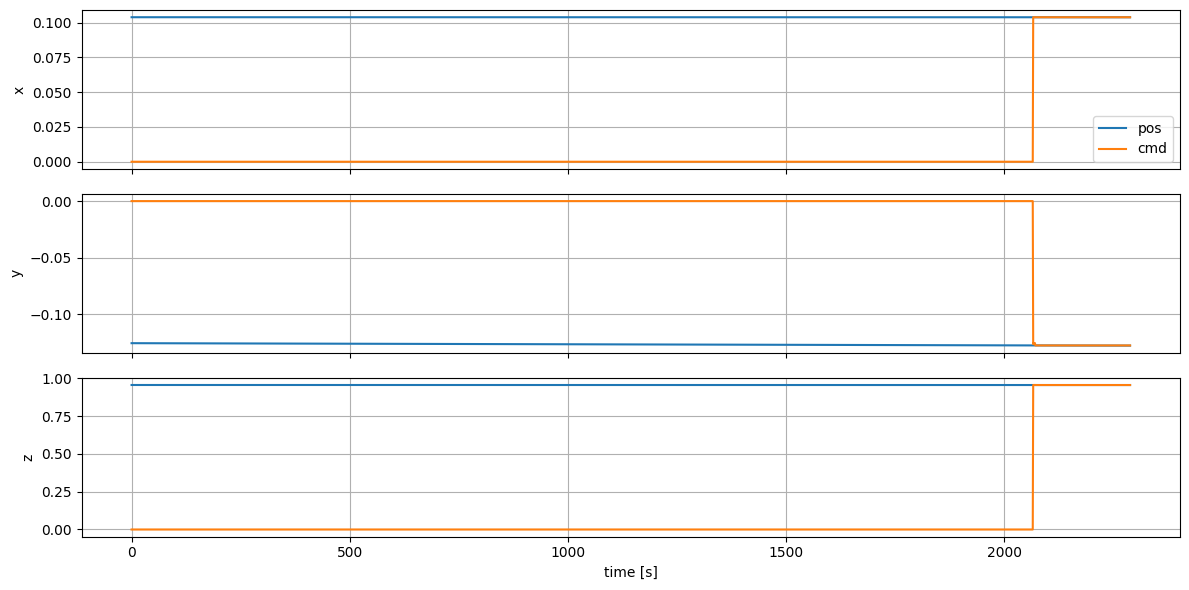

In [7]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(12, 6))

labels = ["x", "y", "z"]

for i in range(3):
    axs[i].plot(pos[:, i])
    axs[i].plot(pos_cmd[:, i])
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)

axs[0].legend(["pos", "cmd"])
axs[-1].set_xlabel("time [s]")

plt.tight_layout()
plt.show()

plt.show()

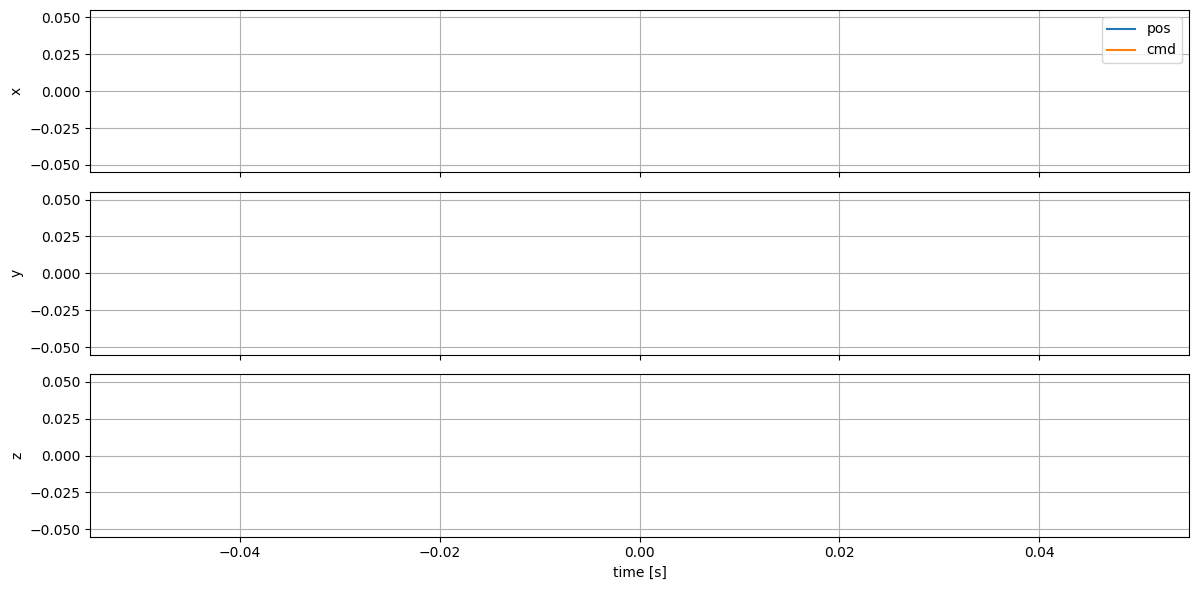

In [8]:
start, stop = 20000, 25000
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(12, 6))
labels = ["x", "y", "z"]

for i in range(3):
    axs[i].plot(data["time"][start:stop], pos[start:stop, i])
    axs[i].plot(data["time"][start:stop], pos_cmd[start:stop, i])
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)

axs[0].legend(["pos", "cmd"])
axs[-1].set_xlabel("time [s]")

plt.tight_layout()
plt.show()

plt.show()

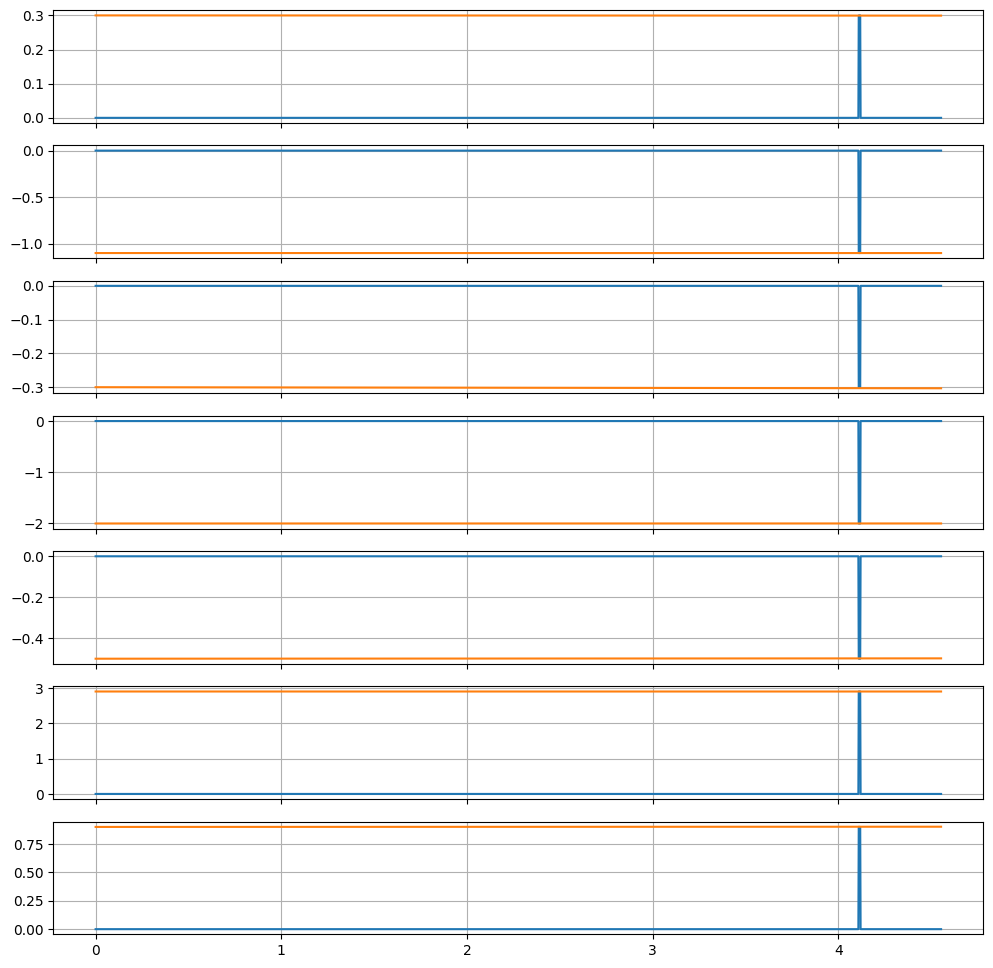

In [9]:


fig, axs = plt.subplots(7, 1, sharex=True, figsize=(12, 12))
for i in range(7):
    axs[i].plot(data["time"], data["q_cmd"][:, i])
    axs[i].plot(data["time"], data["q"][:, i])
    axs[i].grid(True)
plt.show()

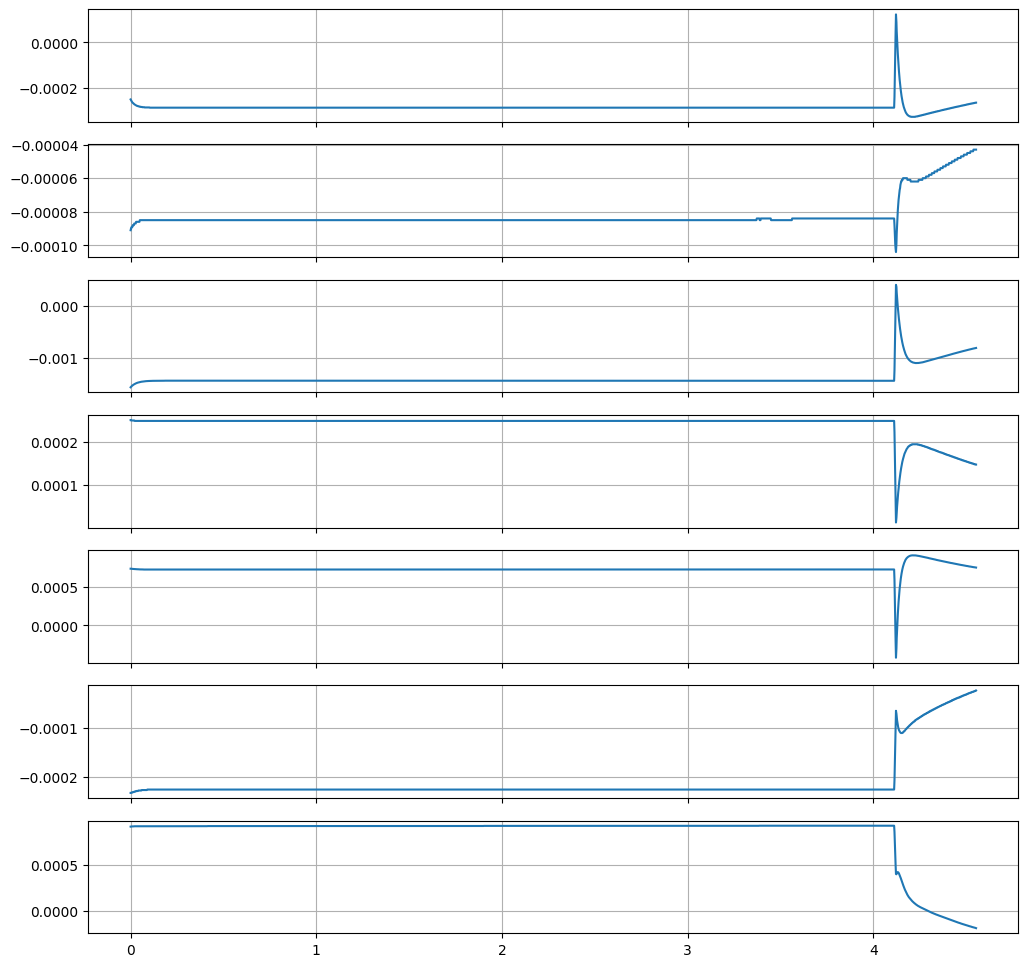

In [10]:
fig, axs = plt.subplots(7, 1, sharex=True, figsize=(12, 12))
for i in range(7):
    axs[i].plot(data["time"], data["dq"][:, i])
    axs[i].grid(True)
plt.show()